In [2]:

import pandas as pd

df_titanic = pd.read_csv('data/titanic/train.csv')

In [3]:
df_titanic['Embarked']

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

In [4]:
pd.get_dummies(df_titanic['Embarked'], prefix='Embarked', dummy_na=True)

,Embarked_C,Embarked_Q,Embarked_S,Embarked_nan
0,False,False,True,False
1,True,False,False,False
2,False,False,True,False
3,False,False,True,False
4,False,False,True,False
...,...,...,...,...
886,False,False,True,False
887,False,False,True,False
888,False,False,True,False
889,True,False,False,False


In [5]:
# prova con OneHotEncoder di sklearn
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit_transform(df_titanic[['Embarked']])

array([[0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.]], shape=(891, 4))

In [6]:
df_titanic['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [11]:
df_titanic['Age'].head(6)

0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
5     NaN
Name: Age, dtype: float64

In [12]:
#StandardScaler di sklearn
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
age_scaled = scaler.fit_transform(df_titanic[['Age']])
age_scaled

array([[-0.53037664],
       [ 0.57183099],
       [-0.25482473],
       [ 0.36516706],
       [ 0.36516706],
       [        nan],
       [ 1.67403863],
       [-1.90813618],
       [-0.18593675],
       [-1.08148046],
       [-1.77036023],
       [ 1.94959054],
       [-0.6681526 ],
       [ 0.64071897],
       [-1.08148046],
       [ 1.74292661],
       [-1.90813618],
       [        nan],
       [ 0.08961515],
       [        nan],
       [ 0.36516706],
       [ 0.29627909],
       [-1.01259248],
       [-0.11704878],
       [-1.49480832],
       [ 0.57183099],
       [        nan],
       [-0.73704057],
       [        nan],
       [        nan],
       [ 0.70960695],
       [        nan],
       [        nan],
       [ 2.50069435],
       [-0.11704878],
       [ 0.8473829 ],
       [        nan],
       [-0.59926462],
       [-0.80592855],
       [-1.08148046],
       [ 0.70960695],
       [-0.18593675],
       [        nan],
       [-1.83924821],
       [-0.73704057],
       [  

Text(0, 0.5, 'Frequenza')

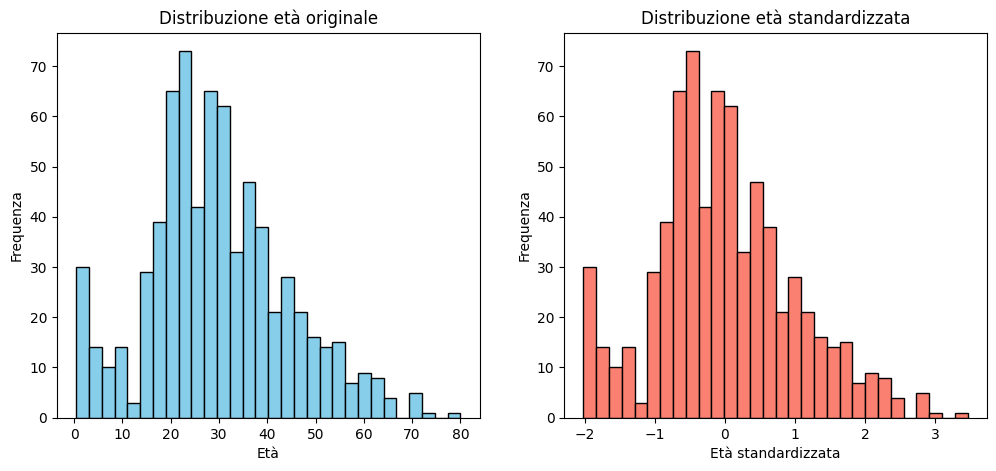

In [14]:
import matplotlib.pyplot as plt

# plt.hist(age_scaled[~pd.isna(age_scaled)], bins=30)
# plt.title('Distribuzione età standardizzata')

fig, ax = plt.subplots(1,2, figsize=(12,5))

ax1, ax2 = ax

ax1.hist(df_titanic['Age'].dropna(), bins=30, color='skyblue', edgecolor='black')
ax1.set_title('Distribuzione età originale')   
ax1.set_xlabel('Età')
ax1.set_ylabel('Frequenza')
ax2.hist(age_scaled[~pd.isna(age_scaled)], bins=30, color='salmon', edgecolor='black')
ax2.set_title('Distribuzione età standardizzata')  
ax2.set_xlabel('Età standardizzata')
ax2.set_ylabel('Frequenza')

In [29]:
# OneHotEncoder per Embarked e Sex insieme
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_features = encoder.fit_transform(df_titanic[['Embarked', 'Sex']])
encoded_features

array([[0., 0., 1., 0., 0., 1.],
       [1., 0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 1., 0.],
       ...,
       [0., 0., 1., 0., 1., 0.],
       [1., 0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0., 1.]], shape=(891, 6))

In [28]:
encoded_feature_names = encoder.get_feature_names_out(['Embarked', 'Sex'])
encoded_feature_names

array(['Embarked_C', 'Embarked_Q', 'Embarked_S', 'Embarked_nan',
       'Sex_female', 'Sex_male'], dtype=object)

In [18]:
pd.DataFrame(encoded_features, columns=encoded_feature_names)

,Embarked_C,Embarked_Q,Embarked_S,Embarked_nan,Sex_female,Sex_male
0,0.0,0.0,1.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...
886,0.0,0.0,1.0,0.0,0.0,1.0
887,0.0,0.0,1.0,0.0,1.0,0.0
888,0.0,0.0,1.0,0.0,1.0,0.0
889,1.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
# OneHotEncoder per Age - NON SERVE A MOLTO, perchè Age è una variabile continua

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
Age_encoded = encoder.fit_transform(df_titanic[['Age']])
Age_encoded

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(891, 89))

In [22]:
encoder.get_feature_names_out(['Age'])

array(['Age_0.42', 'Age_0.67', 'Age_0.75', 'Age_0.83', 'Age_0.92',
       'Age_1.0', 'Age_2.0', 'Age_3.0', 'Age_4.0', 'Age_5.0', 'Age_6.0',
       'Age_7.0', 'Age_8.0', 'Age_9.0', 'Age_10.0', 'Age_11.0',
       'Age_12.0', 'Age_13.0', 'Age_14.0', 'Age_14.5', 'Age_15.0',
       'Age_16.0', 'Age_17.0', 'Age_18.0', 'Age_19.0', 'Age_20.0',
       'Age_20.5', 'Age_21.0', 'Age_22.0', 'Age_23.0', 'Age_23.5',
       'Age_24.0', 'Age_24.5', 'Age_25.0', 'Age_26.0', 'Age_27.0',
       'Age_28.0', 'Age_28.5', 'Age_29.0', 'Age_30.0', 'Age_30.5',
       'Age_31.0', 'Age_32.0', 'Age_32.5', 'Age_33.0', 'Age_34.0',
       'Age_34.5', 'Age_35.0', 'Age_36.0', 'Age_36.5', 'Age_37.0',
       'Age_38.0', 'Age_39.0', 'Age_40.0', 'Age_40.5', 'Age_41.0',
       'Age_42.0', 'Age_43.0', 'Age_44.0', 'Age_45.0', 'Age_45.5',
       'Age_46.0', 'Age_47.0', 'Age_48.0', 'Age_49.0', 'Age_50.0',
       'Age_51.0', 'Age_52.0', 'Age_53.0', 'Age_54.0', 'Age_55.0',
       'Age_55.5', 'Age_56.0', 'Age_57.0', 'Age_58.0', 'Age

In [24]:
from sklearn.preprocessing import Normalizer
normalizer = Normalizer()
# age_normalized = normalizer.fit_transform(df_titanic[['Age']])# da errore perché ci sono NaN
# age_normalized

In [25]:
#usiamo un Imputer per riempire i NaN prima di normalizzare
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
age_imputed = imputer.fit_transform(df_titanic[['Age']])
age_normalized = normalizer.fit_transform(age_imputed)
age_normalized

array([[1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],

(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0., 891.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.]),
 array([0.5       , 0.53333333, 0.56666667, 0.6       , 0.63333333,
        0.66666667, 0.7       , 0.73333333, 0.76666667, 0.8       ,
        0.83333333, 0.86666667, 0.9       , 0.93333333, 0.96666667,
        1.        , 1.03333333, 1.06666667, 1.1       , 1.13333333,
        1.16666667, 1.2       , 1.23333333, 1.26666667, 1.3       ,
        1.33333333, 1.36666667, 1.4       , 1.43333333, 1.46666667,
        1.5       ]),
 <BarContainer object of 30 artists>)

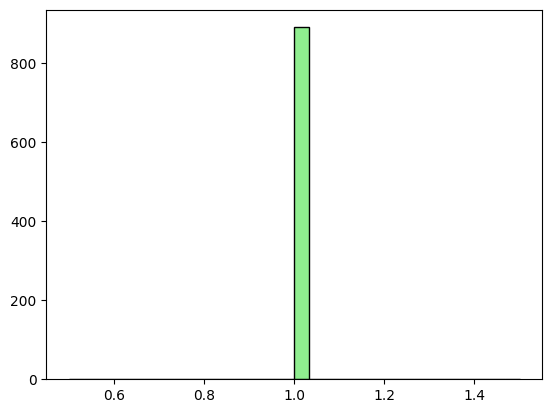

In [26]:
plt.hist(age_normalized, bins=30, color='lightgreen', edgecolor='black')

anche qui, Normalizer non sarà utile con questi dati

In [30]:
#ColumnTransformer per combinare più trasformazioni
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ('age_filler', SimpleImputer(strategy='mean'), ['Age']),
    ('category_encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['Embarked'])
    ]
)
preprocessed_data = preprocessor.fit_transform(df_titanic)
preprocessed_data

array([[22.        ,  0.        ,  0.        ,  1.        ,  0.        ],
       [38.        ,  1.        ,  0.        ,  0.        ,  0.        ],
       [26.        ,  0.        ,  0.        ,  1.        ,  0.        ],
       ...,
       [29.69911765,  0.        ,  0.        ,  1.        ,  0.        ],
       [26.        ,  1.        ,  0.        ,  0.        ,  0.        ],
       [32.        ,  0.        ,  1.        ,  0.        ,  0.        ]],
      shape=(891, 5))

In [31]:
pd.DataFrame(preprocessed_data, columns=preprocessor.get_feature_names_out())

,age_filler__Age,category_encoder__Embarked_C,category_encoder__Embarked_Q,category_encoder__Embarked_S,category_encoder__Embarked_nan
0,22.000000,0.0,0.0,1.0,0.0
1,38.000000,1.0,0.0,0.0,0.0
2,26.000000,0.0,0.0,1.0,0.0
3,35.000000,0.0,0.0,1.0,0.0
4,35.000000,0.0,0.0,1.0,0.0
...,...,...,...,...,...
886,27.000000,0.0,0.0,1.0,0.0
887,19.000000,0.0,0.0,1.0,0.0
888,29.699118,0.0,0.0,1.0,0.0
889,26.000000,1.0,0.0,0.0,0.0


In [32]:
# make_pipeline
from sklearn.pipeline import make_pipeline

category_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore', sparse_output=False)
)
category_pipeline.fit_transform(df_titanic[['Embarked']])

array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       ...,
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]], shape=(891, 3))

In [33]:
preprocessor = ColumnTransformer(transformers=[
    ('cat', category_pipeline, ['Embarked', 'Sex']),
    ('num', SimpleImputer(strategy='mean'), ['Age', 'Fare'])
    ]
)


In [35]:
#uguale alla cella precedente, solo che uso make_pipeline direttamente dentro ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('cat', make_pipeline(
            SimpleImputer(strategy='most_frequent'),
            OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        ), ['Embarked', 'Sex']),
    ('num', SimpleImputer(strategy='mean'), ['Age', 'Fare'])
    ]
)


In [36]:

preprocessed_data = preprocessor.fit_transform(df_titanic)
preprocessed_data

array([[ 0.        ,  0.        ,  1.        , ...,  1.        ,
        22.        ,  7.25      ],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
        38.        , 71.2833    ],
       [ 0.        ,  0.        ,  1.        , ...,  0.        ,
        26.        ,  7.925     ],
       ...,
       [ 0.        ,  0.        ,  1.        , ...,  0.        ,
        29.69911765, 23.45      ],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
        26.        , 30.        ],
       [ 0.        ,  1.        ,  0.        , ...,  1.        ,
        32.        ,  7.75      ]], shape=(891, 7))

In [ ]:
#train_test_split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df_titanic.drop(columns=['Survived']),
    df_titanic['Survived'],
    test_size=0.2,
    random_state=42)

In [42]:
#RandomForestClassifier con pipeline di preprocessing
from sklearn.ensemble import RandomForestClassifier
model = make_pipeline(
    preprocessor,
    RandomForestClassifier(n_estimators=100, random_state=42)
)
model.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('randomforestclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [43]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 1])

In [44]:
model.score(X_test, y_test)

0.7541899441340782

In [ ]:
#esporto la versione "finale" del modello con pickle
import pickle

with open('data/titanic/titanic_model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [ ]:
#import pickle
from sklearn.pipeline import Pipeline

#importo il modello salvato con pickle, così non rifaccio training ogni volta
with open('data/titanic/titanic_model.pkl', 'rb') as f:
    loaded_model:Pipeline = pickle.load(f) #uso typing per specificare il tipo di oggetto che sto caricando da pickle
    #type of loaded_model
    print(type(loaded_model))

    #faccio solo delle predizioni con il modello caricato
    # loaded_model.predict(X_test)

<class 'sklearn.pipeline.Pipeline'>
